# **Метод оценки потенциала возвращения функционального назначения советским зданиям**

# Этап: Сбор исходных данных
На данном этапе следует собрать исходные данные для исследуемого объекта.



In [ ]:
name="Клуб мастеровых фабрики Торнтона" #Наименование объекта
adress="г. Санкт-Петербург, ул. Тельмана, 8" #Адрес
functional_zone="Общественно-деловая зона" #Функциональная зона территории
land_use="ЗРЗ(12)06" #Режим использования земель
size_land=874 #Размер земельного участка
area=1183.3 #Площадь здания
building_area=770 #Площадь застройки
land_area=75 #Площадь озеленения участка
year_of_commissioning=1912 #Год ввода в эксплуатацию
year_of_termination=2014 #Год прекращения функции образовательной организации
new_feature="жилая" #Новая функция
capacity=200 #Проектная вместимость здания
project_type="Индивидуальный проект" #Тип проекта
architectural_style="Кирпичный" #Архитектурный стиль
decoration=False #Наличие исторической отделки
historical_building=True #Историческое здание
technical_condition="Исправное" #Техническое состояние здания
material="Кирпич, дерево, металл" #Материал наружных стен, перекрытий, кровли
communications=True #Подключение к городским коммуникациям

# Этап: сопоставление исходных данных для каждого критерия
Для этой оценки необходимо каждому критерию сопоставить прямые исходные данные (если критерий основан на измеряемых показателях), либо расчетные значения (если критерий требует дополнительных вычислений). Полученные значения затем сравниваются с нормой – установленными нормативными требованиями или эталонными значениями.  Оценка выполняется по такому принципу: 1 балл – данные соответствуют либо выше нормы, 0 баллов – данные не соответствуют норме.

Архитектурно-планировочные (K1):

In [ ]:
k1_1=size_land/capacity #Оптимальный размер земельного участка

In [ ]:
k1_1

4.37

In [ ]:
def check_k1_1(size_land, capacity):
    """
    Проверяет критерий k1_1 на основе результата формулы

    Параметры:
    k1_1 - результат расчета формулы k1_1 (в м²)

    Возвращает:
    1 - если результат > 2.5 м²
    0 - если результат <= 2.5 м²
    """
    return 1 if k1_1 > 2.5 else 0
   # Использование
# Использование
k1_1 = check_k1_1(size_land, capacity)
k1_1

1

In [ ]:
n2=0.1 #n1-минимальный процент свободной площади

In [ ]:
k1_2=(size_land-(land_area+building_area+n2*size_land))/capacity #Оптимальная площадь открытых площадок

In [ ]:
k1_2

-0.29199999999999987

In [ ]:
def check_k1_2(size_land, land_area, building_area, n2, capacity):
    """
    Проверяет критерий k1_2

    Параметры:
    size_land - общая площадь участка (м²)
    land_area - площадь озеленения/ландшафта (м²)
    building_area - площадь застройки (м²)
    n2 - коэффициент (доля от общей площади, например 0.1 для 10%)
    capacity - количество мест/вместимость

    Возвращает:
    1 - если площадь на одно место > 4 м²
    0 - если площадь на одно место <= 4 м² или capacity = 0
    """

    # Проверяем, чтобы избежать деления на ноль
    if capacity == 0:
        return 0

    # Рассчитываем свободную площадь
    free_area = size_land - (land_area + building_area + n2 * size_land)

    # Рассчитываем площадь на одно место
    area_per_person = free_area / capacity

    # Проверяем критерий: больше 4 м² на место -> 1, иначе -> 0
    return 1 if area_per_person > 4 else 0
    # Использование
k1_2 = check_k1_2(size_land, land_area, building_area, n2, capacity)
k1_2


0

In [ ]:
k1_3=(size_land-(building_area+land_area+0.1*size_land+4* capacity))/capacity #Оптимальная площадь зон отдыха на участке
k1_3

-4.292000000000001

In [ ]:
def check_k1_3(k1_3):
    """
    Проверяет критерий k1_1 на основе результата формулы

    Параметры:
    k1_3 - результат расчета формулы k1_3 (в м²)

    Возвращает:
    1 - если результат > 2 м²
    0 - если результат <= 2 м²
    """
    return 1 if k1_3 > 2 else 0
   # Использование
k1_3 = check_k1_3(k1_3)
k1_3

0

In [ ]:
k1_4=size_land-building_area #Оптимальная площадь хозяйственной зоны
k1_4

104

In [ ]:
def check_k1_4(k1_4):
    """
    Проверяет критерий k1_4:
    1 - если значение > 10% от size_land
    0 - если значение <= 10% от size_land

    Параметры:
    value - проверяемое значение (например, площадь чего-либо)
    size_land - общая площадь земельного участка
    """
    # Рассчитываем 10% от размера участка
    ten_percent = size_land * 0.10

    # Проверяем условие
    return 1 if k1_4 > ten_percent else 0
# Использование
k1_4 = check_k1_4(k1_4)
k1_4

1

In [ ]:
k1_5=new_feature #Соответствие объемно-планировочной структуры типологии

In [ ]:
def check_k1_5(k1_5):
    """
    Проверяет критерий k1_5:
    1 - если тип здания: образовательная, административная, социальная, жилая
    0 - для других типов

    Параметры:
    k1_5 - тип здания (строка)
    """
    # Список разрешенных типов (приводим к нижнему регистру для сравнения)
    allowed_types = ['образовательная', 'административная', 'социальная', 'жилая']

 # Проверяем, что k1_5 - строка
    if isinstance(k1_5, str):
        # Приводим к нижнему регистру и удаляем лишние пробелы
        building_type_normalized = k1_5.strip().lower()

        # Проверяем, содержится ли тип в списке разрешенных
        return 1 if building_type_normalized in allowed_types else 0
    else:
        # Если передан не строковый тип, возвращаем 0
        return 0
    # Использование
k1_5 = check_k1_5(k1_5)
k1_5

1

In [ ]:
k1_6=area/capacity #Необходимая площадь здания
k1_6

5.9165

In [ ]:
def check_k1_6(k1_6):
    """
    Проверяет критерий k1_6:
    1 - если количество м² на посетителя >= 1
    0 - если количество м² на посетителя < 1

    Параметры:
    area_per_student - площадь на одного обучающегося (м²)
    """
    return 1 if k1_6 >= 1 else 0
  # Использование
k1_6 = check_k1_6(k1_6)
k1_6

1

In [ ]:
k1_7=1 #Наличие зальных помещений

In [ ]:
k1_8=new_feature #Современное функциональное использование

In [ ]:
def check_k1_8(k1_8):
    """
    Проверяет критерий k1_8:
    1 - если тип здания: административная, торговая, социальная, культурная
    0 - для других типов

    Параметры:
    k1_5 - тип здания (строка)
    """
    # Список разрешенных типов (приводим к нижнему регистру для сравнения)
    allowed_types = ['торговая', 'административная', 'социальная', 'культурная']

 # Проверяем, что k1_8 - строка
    if isinstance(k1_8, str):
        # Приводим к нижнему регистру и удаляем лишние пробелы
        building_type_normalized = k1_8.strip().lower()

        # Проверяем, содержится ли тип в списке разрешенных
        return 1 if building_type_normalized in allowed_types else 0
    else:
        # Если передан не строковый тип, возвращаем 0
        return 0
    # Использование
k1_8 = check_k1_8(k1_8)
k1_8

0

In [ ]:
k1_9=size_land-(building_area+land_area+4*capacity+2*capacity+0.1*size_land) #Возможность строительства зданий на участке
k1_9

-1258.4

In [ ]:
def check_k1_9(k1_9):
    """
    Проверяет критерий k1_9:
    1 - если значение > 10% от size_land
    0 - если значение <= 10% от size_land

    Параметры:
    value - проверяемое значение (например, площадь чего-либо)
    size_land - общая площадь земельного участка
    """
    # Рассчитываем 10% от размера участка
    ten_percent = size_land * 0.10

    # Проверяем условие
    return 1 if k1_9 > ten_percent else 0
# Использование
k1_9 = check_k1_9(k1_9)
k1_9

0

Социально-экономические (K2)

In [ ]:
k2_1=1 #Качество окружающего воздуха

In [ ]:
k2_2=1 #Акустический комфорт


In [ ]:
k2_3=1 #Естественное освещение

In [ ]:
k2_4=land_area #Озелененная территория участка
k2_4

75

In [ ]:
def check_k2_4(k2_4):
    """
    Проверяет критерий k2_4:
    1 - если значение > 10% от size_land
    0 - если значение <= 10% от size_land

    Параметры:
    value - проверяемое значение (например, площадь чего-либо)
    size_land - общая площадь земельного участка
    """
    # Рассчитываем 10% от размера участка
    ten_percent = size_land * 0.10

    # Проверяем условие
    return 1 if k2_4 > ten_percent else 0
# Использование
k2_4 = check_k2_4(k2_4)
k2_4

0

In [ ]:
k2_5=1 #Соответствующая функциональная зона территории

In [ ]:
k2_6=1 #Транспортная доступность

In [ ]:
k2_7=1 #Настоящая необходимость в учреждении

In [ ]:
k2_8=1 #Возможная необходимость в учреждении

In [ ]:
k2_9=technical_condition #Работы, необходимые для восстановления функции

In [ ]:
def check_k2_9(k2_9):
    """
    Проверяет критерий k2_9:
    1 - если тип здания: административная, торговая, социальная, культурная
    0 - для других типов

    Параметры:
    k2_9- тип здания (строка)
    """
    # Список разрешенных типов (приводим к нижнему регистру для сравнения)
    allowed_types = ['исправное', 'работоспособное']

 # Проверяем, что k2_9 - строка
    if isinstance(k2_9, str):
        # Приводим к нижнему регистру и удаляем лишние пробелы
        building_type_normalized = k2_9.strip().lower()

        # Проверяем, содержится ли тип в списке разрешенных
        return 1 if building_type_normalized in allowed_types else 0
    else:
        # Если передан не строковый тип, возвращаем 0
        return 0
    # Использование
k2_9 = check_k2_9(k2_9)
k2_9

1

Инженерно-технические (K3):ччастично заполняется вручную

In [ ]:
k3_1=1 #Возможность устройства пожарного проезда

In [ ]:
k3_2=material #Пожароопасность конструкций

In [ ]:
def check_k3_2(k3_2):
    """
    Проверяет критерий k3_2:
    1 - если строка содержит: бетон, железобетон, сталь, кирпич
    0 - если не содержит ни одного из этих материалов

    Параметры:
    k3_2- строка с описанием материалов
    """
    if not isinstance(k3_2, str):
        return 0

    # Приводим к нижнему регистру для сравнения
    material_string_lower = k3_2.lower()

    # Список искомых материалов
    target_materials = ['бетон', 'железобетон', 'сталь', 'кирпич']

    # Проверяем, содержит ли строка хотя бы один из материалов
    for material in target_materials:
        if material in material_string_lower:
            return 1

    # Если ни один материал не найден
    return 0
      # Использование
k3_2 = check_k3_2(k3_2)
k3_2

1

In [ ]:
k3_3=1 #Расстояние от границ земельного участка до других объектов

In [ ]:
k3_4=communications #Инженерное оборудование здания

In [ ]:
def check_k3_4(k3_4):
    """
    Проверяет критерий k3_4:
    1 - если значение True (или строка "true")
    0 - если значение False, None, или другое

    Параметры:
    k3_4 - проверяемое значение
    """
    # Если это булево True
    if k3_4 is True:
        return 1
    # Использование
k3_4 = check_k3_4(k3_4)
k3_4

1

In [ ]:
k3_5=technical_condition #Прочность и надежность конструкций

In [ ]:
def check_k3_5(k3_5):
    """
    Проверяет критерий k3_5:
    1 - если тип здания: административная, торговая, социальная, культурная
    0 - для других типов

    Параметры:
    k3_5- тип здания (строка)
    """
    # Список разрешенных типов (приводим к нижнему регистру для сравнения)
    allowed_types = ['исправное', 'работоспособное']

 # Проверяем, что k3_5 - строка
    if isinstance(k3_5, str):
        # Приводим к нижнему регистру и удаляем лишние пробелы
        building_type_normalized = k3_5.strip().lower()

        # Проверяем, содержится ли тип в списке разрешенных
        return 1 if building_type_normalized in allowed_types else 0
    else:
        # Если передан не строковый тип, возвращаем 0
        return 0
    # Использование
k3_5 = check_k3_5(k3_5)
k3_5

1

In [ ]:
k3_6=0 #Сохранность исторической части здания

 Историко-культурные (K4): заполняется вручную

In [ ]:
k4_1=0 #Датировка

In [ ]:
k4_2=1 #Мемориальность

In [ ]:
k4_3=0 #Подлинность

In [ ]:
k4_4=0 #Представительность

In [ ]:
k4_5=0  #Градостроительная ценность

In [ ]:
k4_6=1 #Ансамблевость

In [ ]:
k4_7=0 #Конструктивно-технологическая ценность

In [ ]:
k4_8=0 #Архитектурно-художественная ценность интерьеров

In [ ]:
k4_9=0 #Научно-познавательная ценность

In [ ]:
k4_10=1 #Учебно-педагогическая ценность

In [ ]:
k4_11=0 #Художественно-эстетическая ценность

In [ ]:
k4_12=1 #Публичная и общественная значимость

In [ ]:
k4_13=0 #Социокультурная ценность

In [ ]:
k4_14=0 #Распространённость

In [ ]:
k4_15=1 #Оптимальные режимы использования земель

In [ ]:
k4_16=1 #Этапность

In [ ]:
k4_17=0 #Видимость

# Расчет суммарного бала для каждой категории критериев:

Для группы критериев K1:

In [ ]:
#i_1=(k1_1+k1_2+k1_3+k1_4+k1_5+k1_6+k1_7+k1_8+k1_9)/9
i_1=0.67

Для группы критериев K2:

In [ ]:
#i_2=(k2_1+k2_2+k2_3+k2_4+k2_5+k2_6+k2_7+k2_8+k2_9)/9
i_2=0.89

Для группы критериев K3:

In [ ]:
#i_3=(k3_1+k3_2+k3_3+k3_4+k3_5+k3_6)/6
i_3=1

Для группы критериев K4:

In [ ]:
#i_4=(k4_1+k4_2+k4_3+k4_4+k4_5+k4_6+k4_7+k4_8+k4_9+k4_10+k4_11+k4_12+k4_13+k4_14+k4_15+k4_16+k4_17)/17
i_4=0.82

Общий балл вычисляется по формуле:

In [ ]:
I=i_1+i_2+i_3+i_4

# Рекомендации:

In [ ]:
def get_total_score_recommendation(I):
    """
    Возвращает рекомендацию по общему баллу I

    Параметры:
    I - общий балл (от 0 до 4)
    """
    if 0 <= I < 1:
        level = "низкий"
        recommendation = "В здании невозможно и не требуется восстановить образовательную функцию. Требуется полная реконструкция"
    elif 1 <= I < 2:
        level = "ограниченный"
        recommendation = "В здании возможно восстановление функции, но это требует значительных ресурсов и инвестиций"
    elif 2 <= I < 3:
        level = "оптимальный"
        recommendation = "В здании возможно восстановление функции после проведения определенных работ"
    elif 3 <= I <= 4:
        level = "высокий"
        recommendation = "В здании необходимо и возможно восстановить функцию"
    else:
        return "Ошибка: значение I должно быть от 0 до 4"

    return f"Общий балл I = {I:.2f}\Уровень потенциала: {level}\Рекомендация: {recommendation}"


In [ ]:
get_total_score_recommendation(I)

'Общий балл I = 2.67\\Уровень потенциала: оптимальный\\Рекомендация: В здании возможно восстановление функции после проведения определенных работ'

In [ ]:
def get_architecture_recommendation(i_1):
    """
    Возвращает рекомендацию по архитектурно-планировочным критериям i1

    Параметры:
    i_1 - балл по категории i_1 (от 0 до 1)
    """
    if 0 <= i_1 < 0.19:
        level = "низкий"
        recommendation = "Несоответствие нормам, требуется полная реконструкция здания и участка"
    elif 0.19 <= i_1 < 0.5:
        level = "ограниченный"
        recommendation = "Частичное соответствие требованиям, необходимы значительные изменения в перепланировке"
    elif 0.5 <= i_1 < 0.8:
        level = "оптимальный"
        recommendation = "Соответствие основным требованиям, необходимы локальные улучшения в планировке"
    elif 0.8 <= i_1 <= 1:
        level = "высокий"
        recommendation = "Соответствие требованиям, здание готово к использованию"
    else:
        return "Ошибка: значение i1 должно быть от 0 до 1"

    return f"Категория архитектурно-планировочные критерии (i_1 = {i_1:.2f}):\Уровень потенциала: {level}\Рекомендация: {recommendation}"


In [ ]:
get_architecture_recommendation(i_1)

'Категория архитектурно-планировочные критерии (i_1 = 0.00):\\Уровень потенциала: низкий\\Рекомендация: Несоответствие нормам, требуется полная реконструкция здания и участка'

In [ ]:
def get_socio_economic_recommendation(i_2):
    """
    Возвращает рекомендацию по социально-экономическим критериям i_2

    Параметры:
    i2_ - балл по категории i_2 (от 0 до 1)
    """
    if 0 <= i_2 < 0.19:
        level = "низкий"
        recommendation = "Объект не пригоден из-за низкого качества воздуха, высокого шума и транспортной доступности"
    elif 0.19 <= i_2 < 0.5:
        level = "ограниченный"
        recommendation = "Частичное соответствие требованиям, необходимы значительные изменения и экономические затраты"
    elif 0.5 <= i_2 < 0.8:
        level = "оптимальный"
        recommendation = "Соответствие основным требованиям, необходимы локальные изменения в части санитарно-гигиенических норм"
    elif 0.8 <= i_2 <= 1:
        level = "высокий"
        recommendation = "Соответствие требованиям, здание готово к использованию"
    else:
        return "Ошибка: значение i_2 должно быть от 0 до 1"

    return f"Категория социально-экономические критерии (i_2 = {i_2:.2f}):\Уровень потенциала: {level}\Рекомендация: {recommendation}"

In [ ]:
get_socio_economic_recommendation(i_2)

'Категория социально-экономические критерии (i_2 = 0.85):\\Уровень потенциала: высокий\\Рекомендация: Соответствие требованиям, здание готово к использованию'

In [ ]:
def get_engineering_recommendation(i_3):
    """
    Возвращает рекомендацию по инженерно-техническим критериям i_3

    Параметры:
    i_3 - балл по категории i_3 (от 0 до 1)
    """
    if 0 <= i_3 < 0.19:
        level = "низкий"
        recommendation = "Осуществление безопасного нахождения в здании невозможно"
    elif 0.19 <= i_3 < 0.5:
        level = "ограниченный"
        recommendation = "Частичное соответствие требованиям, необходимы значительные изменения и экономические затраты"
    elif 0.5 <= i_3 < 0.8:
        level = "оптимальный"
        recommendation = "Соответствие основным требованиям, необходимы локальные ремонтные изменения"
    elif 0.8 <= i_3 <= 1:
        level = "высокий"
        recommendation = "Соответствие требованиям, здание готово к использованию"
    else:
        return "Ошибка: значение i_3 должно быть от 0 до 1"

    return f"Категория инженерно-технические критерии (i_3 = {i_3:.2f}):\Уровень потенциала: {level}\Рекомендация: {recommendation}"

In [ ]:
get_engineering_recommendation(i_3)

'Категория инженерно-технические критерии (i_3 = 1.00):\\Уровень потенциала: высокий\\Рекомендация: Соответствие требованиям, здание готово к использованию'

In [ ]:
def get_historical_cultural_recommendation(i_4):
    """
    Возвращает рекомендацию по историко-культурным критериям i_4

    Параметры:
    i_4 - балл по категории i_4 (от 0 до 1)
    """
    if 0 <= i_4 < 0.19:
        level = "низкий"
        recommendation = "Объект не представляет исторической и культурной ценности, требуются дополнительные исследования"
    elif 0.19 <= i_4 < 0.5:
        level = "ограниченный"
        recommendation = "Объект частично представляет историческую и культурную ценность, восстановление функции возможно"
    elif 0.5 <= i_4 < 0.8:
        level = "оптимальный"
        recommendation = "Объект представляет историческую и культурную ценность, требуется восстановления функции"
    elif 0.8 <= i_4 <= 1:
        level = "высокий"
        recommendation = "Объект представляет исключительную ценность, требуется сохранение исторического облика и восстановление функции"
    else:
        return "Ошибка: значение i_4 должно быть от 0 до 1"

    return f"Категория историко-культурные критерии (i_4 = {i_4:.2f}):\Уровень потенциала: {level}\Рекомендация: {recommendation}"

In [ ]:
get_historical_cultural_recommendation(i_4)

'Категория историко-культурные критерии (i_4 = 0.82):\\Уровень потенциала: высокий\\Рекомендация: Объект представляет исключительную ценность, требуется сохранение исторического облика и восстановление функции'

# Диаграмма по значениям:

In [ ]:
i_1=0.44
i_2=0.89
i_3=0.83
i_4=0.12


In [ ]:
# Установка и импорт библиотек (если нужно)
!pip install matplotlib -q

import matplotlib.pyplot as plt
import numpy as np

def create_potential_chart(i_1, i_2, i_3, i_4):
    """
    Создает круговую диаграмму с оценками потенциала по 4 категориям

    Параметры:
    i_1, i_2, i_3, i_4 - значения от 0 до 1
    """
    # Проверка входных значений
    values = [i_1, i_2, i_3, i_4]
    for i, val in enumerate(values, 1):
        if not 0 <= val <= 1:
            print(f"Ошибка: значение i_{i} = {val} должно быть от 0 до 1")
            return

    # Данные для диаграммы
    categories = ['Архитектурно-\nпланировочные',
                  'Социально-\nэкономические',
                  'Инженерно-\nтехнические',
                  'Историко-\nкультурные']

    # Создаем фигуру
    fig, ax = plt.subplots(figsize=(10, 8))

    # Определяем цвета в зависимости от значений
    colors = []
    for val in values:
        if 0 <= val < 0.2:
            colors.append('#FF6B6B')  # красный
        elif 0.2 <= val < 0.5:
            colors.append('#FF8C42')  # желтый
        elif 0.5 <= val < 0.8:
            colors.append('#FFD700')  # голубой
        else:  # 0.8 - 1
            colors.append('#4CAF50')  # зеленый

    # Создаем круговую диаграмму БЕЗ стандартных процентов
    wedges, texts, autotexts = ax.pie(values,
                                      labels=categories,
                                      colors=colors,
                                      autopct='',  # Пустая строка - убираем стандартные проценты
                                      startangle=90,
                                      textprops={'fontsize': 12})

    # ВРУЧНУЮ добавляем значения в центры секторов
    # Вычисляем углы для размещения текста
    theta1 = ax.patches[0].theta1  # начальный угол первого сектора
    theta2 = ax.patches[0].theta2  # конечный угол первого сектора

    for i, (wedge, value) in enumerate(zip(wedges, values)):
        # Вычисляем средний угол сектора
        center_angle = (wedge.theta1 + wedge.theta2) / 2
        # Преобразуем угол в радианы
        angle_rad = np.deg2rad(center_angle)

        # Вычисляем позицию для текста (немного смещаем от центра)
        # 0.5 - это расстояние от центра (0-1)
        x = 0.5 * np.cos(angle_rad)
        y = 0.5 * np.sin(angle_rad)

        # Добавляем текст со значением
        ax.text(x, y,
                f'i_{i+1}\n{value:.2f}',  # Форматируем: i_1\n0.60
                ha='center',
                va='center',
                fontsize=11,
                fontweight='bold',
                color='black',
                bbox=dict(boxstyle='round',
                         facecolor='white',
                         alpha=0.8,
                         edgecolor='gray',
                         linewidth=1))

    # Добавляем заголовок
    ax.set_title('Диаграмма оценки потенциала здания',
                 fontsize=16, fontweight='bold', pad=20)

    # Добавляем легенду с цветовой кодировкой
    legend_labels = [
        'Очень низкий (0-0.19)',
        'Низкий (0.2-0.49)',
        'Средний (0.5-0.79)',
        'Высокий (0.8-1)'
    ]
    legend_colors = ['#FF6B6B', '#FFD166', '#4ECDC4', '#06D6A0']

    # Создаем патчи для легенды
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=label)
                       for color, label in zip(legend_colors, legend_labels)]

    ax.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              fontsize=11,
              title='Уровень потенциала',
              title_fontsize=12)

    # Устанавливаем соотношение сторон, чтобы круг был кругом
    ax.axis('equal')

    # Добавляем подпись с итоговой информацией
    total_score = np.mean(values) * 4  # Среднее * 4 для масштаба 0-4
    plt.figtext(0.5, 0.01,
                f'Общий балл I = {total_score:.2f} (из 4.0)',
                ha='center',
                fontsize=12,
                fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # Выводим текстовую интерпретацию
    print("\n" + "="*60)
    print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
    print("="*60)

    category_names = ['i₁ (архитектурно-планировочные)',
                     'i₂ (социально-экономические)',
                     'i₃ (инженерно-технические)',
                     'i₄ (историко-культурные)']

    for i, (val, cat) in enumerate(zip(values, category_names), 1):
        if 0 <= val < 0.2:
            level = "Очень низкий"
        elif 0.2 <= val < 0.5:
            level = "Низкий"
        elif 0.5 <= val < 0.8:
            level = "Средний"
        else:
            level = "Высокий"

        print(f"{cat}: {val:.2f} → {level} уровень потенциала")

    print("\nОбщий балл I = {:.2f}/4.0".format(total_score))



# Функция для интерактивного ввода
def interactive_chart():
    """Функция для интерактивного ввода значений"""
    print("\n" + "="*60)
    print("ИНТЕРАКТИВНЫЙ ВВОД ДАННЫХ")
    print("="*60)

    try:
        i_1 = float(input("Введите значение i₁ (архитектурно-планировочные, 0-1): "))
        i_2 = float(input("Введите значение i₂ (социально-экономические, 0-1): "))
        i_3 = float(input("Введите значение i₃ (инженерно-технические, 0-1): "))
        i_4 = float(input("Введите значение i₄ (историко-культурные, 0-1): "))

        print("\n" + "="*60)
        print("ГЕНЕРАЦИЯ ДИАГРАММЫ...")
        print("="*60)

        create_potential_chart(i_1, i_2, i_3, i_4)

    except ValueError:
        print("Ошибка: пожалуйста, вводите только числа!")
    except Exception as e:
        print(f"Произошла ошибка: {e}")

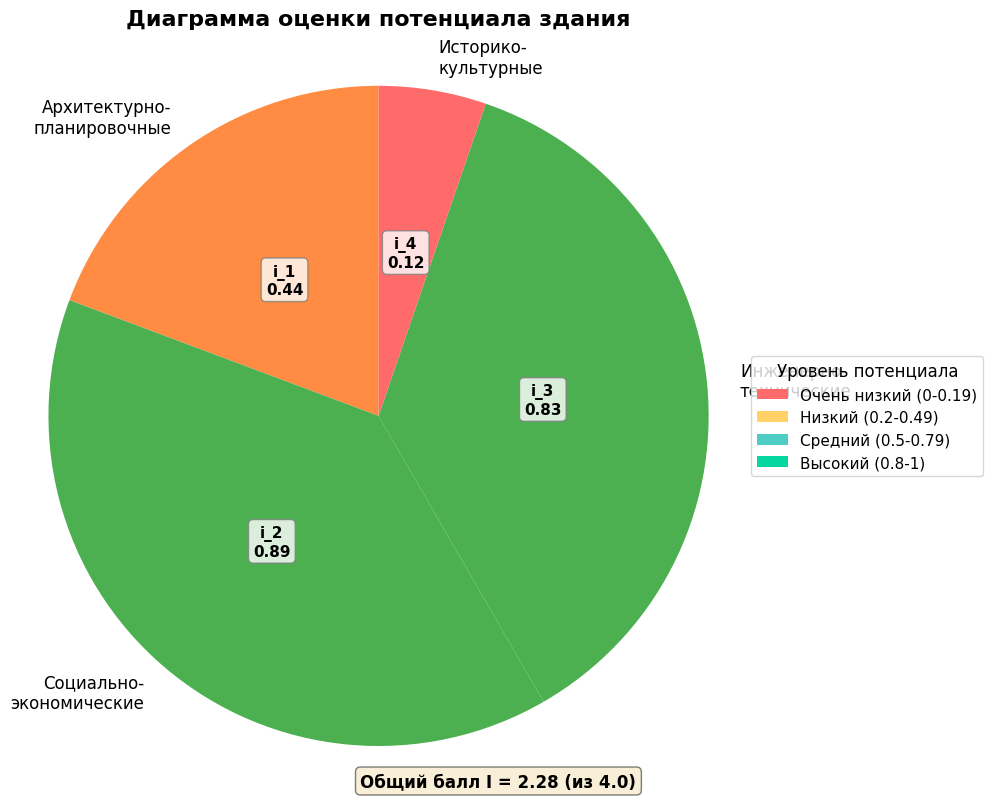


ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
i₁ (архитектурно-планировочные): 0.44 → Низкий уровень потенциала
i₂ (социально-экономические): 0.89 → Высокий уровень потенциала
i₃ (инженерно-технические): 0.83 → Высокий уровень потенциала
i₄ (историко-культурные): 0.12 → Очень низкий уровень потенциала

Общий балл I = 2.28/4.0


In [ ]:
create_potential_chart(i_1, i_2, i_3, i_4)